# 🦷 OralGuard AI - Phase 2: VGG16 Training Pipeline
## Oral Cancer Histopathology Classification System

**Objective**: Train separate VGG16 models for 100x and 400x magnifications and compare with Phase 1 (EfficientNet-B5)

**Key Features**:
- VGG16 with Batch Normalization for stable training
- Same proven data pipeline from Phase 1
- Batch size optimized for VGG16 (12 instead of 16)
- Save predictions for ensemble building (Phase 4)
- Comprehensive comparison with Phase 1 results
- Standalone notebook (runs independently)

## 📦 1. Setup and Imports

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Install required packages
!pip install -q scikit-learn matplotlib seaborn pandas numpy Pillow tqdm

In [3]:
# Core imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep learning imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Image processing
from PIL import Image
import cv2

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

✅ PyTorch version: 2.8.0+cu126
✅ CUDA available: True
✅ GPU: Tesla T4
✅ GPU Memory: 15.83 GB


## ⚙️ 2. Configuration

In [4]:
class Config:
    """Centralized configuration for OralGuard AI Phase 2 training"""

    # Paths
    BASE_PATH = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/Histopathological_Oral_Cancer'
    OUTPUT_DIR = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2'  # VGG16 results here
    PHASE1_RESULTS = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1'  # EfficientNet-B5 results here

    # Data structure
    MAGNIFICATIONS = {
        '100x': {
            'normal': 'First Set/100x_Normal',
            'oscc': 'First Set/100x_OSCC'
        },
        '400x': {
            'normal': 'Second Set/400x_Normal',
            'oscc': 'Second Set/400x_OSCC'
        }
    }

    # Model settings
    MODEL_NAME = 'vgg16_bn'  # VGG16 with Batch Normalization
    IMG_SIZE = 224
    NUM_CLASSES = 2

    # Training hyperparameters (optimized for VGG16 on T4 GPU)
    BATCH_SIZE = 12  # Reduced from 16 for VGG16's larger memory footprint
    EPOCHS = 50
    LEARNING_RATE = 1e-5  # Lower LR for fine-tuning only last layers
    WEIGHT_DECAY = 1e-4

    # Data split
    TRAIN_SPLIT = 0.8
    VAL_SPLIT = 0.1
    TEST_SPLIT = 0.1
    RANDOM_SEED = 42

    # Early stopping
    PATIENCE = 5
    MIN_DELTA = 0.001

    # Mixed precision training for T4 GPU
    USE_AMP = True

    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Class names
    CLASS_NAMES = ['Normal', 'OSCC']

config = Config()

# Create output directory
os.makedirs(config.OUTPUT_DIR, exist_ok=True)
print(f"✅ Configuration loaded")
print(f"📁 Output directory: {config.OUTPUT_DIR}")
print(f"🎯 Device: {config.DEVICE}")
print(f"🏗️ Model: VGG16 with Batch Normalization")
print(f"📦 Batch size: {config.BATCH_SIZE} (optimized for VGG16)")

✅ Configuration loaded
📁 Output directory: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2
🎯 Device: cuda
🏗️ Model: VGG16 with Batch Normalization
📦 Batch size: 12 (optimized for VGG16)


## 📊 3. Data Loading and Preparation (Same as Phase 1)

In [5]:
def load_dataset(base_path, magnification):
    """
    Load dataset for specific magnification level

    Args:
        base_path: Base directory path
        magnification: '100x' or '400x'

    Returns:
        DataFrame with image paths and labels
    """
    data = []
    mag_config = config.MAGNIFICATIONS[magnification]

    # Load Normal images
    normal_path = os.path.join(base_path, mag_config['normal'])
    if os.path.exists(normal_path):
        for img_file in os.listdir(normal_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                data.append({
                    'image_path': os.path.join(normal_path, img_file),
                    'label': 0,  # Normal
                    'label_name': 'Normal',
                    'magnification': magnification
                })

    # Load OSCC images
    oscc_path = os.path.join(base_path, mag_config['oscc'])
    if os.path.exists(oscc_path):
        for img_file in os.listdir(oscc_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                data.append({
                    'image_path': os.path.join(oscc_path, img_file),
                    'label': 1,  # OSCC
                    'label_name': 'OSCC',
                    'magnification': magnification
                })

    df = pd.DataFrame(data)
    print(f"\n📊 {magnification} Dataset:")
    print(f"  Total images: {len(df)}")
    print(f"  Normal: {len(df[df['label']==0])}")
    print(f"  OSCC: {len(df[df['label']==1])}")
    print(f"  Class ratio (OSCC:Normal): {len(df[df['label']==1])/len(df[df['label']==0]):.2f}:1")

    return df

# Load both datasets
print("="*80)
print("Loading datasets...")
print("="*80)

df_100x = load_dataset(config.BASE_PATH, '100x')
df_400x = load_dataset(config.BASE_PATH, '400x')

print(f"\n✅ Datasets loaded successfully!")

Loading datasets...

📊 100x Dataset:
  Total images: 528
  Normal: 89
  OSCC: 439
  Class ratio (OSCC:Normal): 4.93:1

📊 400x Dataset:
  Total images: 696
  Normal: 201
  OSCC: 495
  Class ratio (OSCC:Normal): 2.46:1

✅ Datasets loaded successfully!


In [6]:
def create_stratified_split(df, train_size=0.8, val_size=0.1, test_size=0.1, random_state=42):
    """
    Create stratified train/val/test split

    Args:
        df: DataFrame with image paths and labels
        train_size: Proportion for training (0.8 = 80%)
        val_size: Proportion for validation (0.1 = 10%)
        test_size: Proportion for testing (0.1 = 10%)
        random_state: Random seed for reproducibility

    Returns:
        train_df, val_df, test_df
    """
    # First split: separate test set
    train_val_df, test_df = train_test_split(
        df,
        test_size=test_size,
        stratify=df['label'],
        random_state=random_state
    )

    # Second split: separate validation from training
    val_ratio = val_size / (train_size + val_size)
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=val_ratio,
        stratify=train_val_df['label'],
        random_state=random_state
    )

    print(f"\n📊 Data Split:")
    print(f"  Training:   {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"  Validation: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
    print(f"  Testing:    {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

    # Verify stratification
    for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        normal_count = len(split_df[split_df['label']==0])
        oscc_count = len(split_df[split_df['label']==1])
        print(f"  {split_name}: Normal={normal_count}, OSCC={oscc_count}")

    return train_df, val_df, test_df

# Create splits for both magnifications
print("\n" + "="*80)
print("Creating stratified splits...")
print("="*80)

print("\n🔬 100x Magnification:")
train_100x, val_100x, test_100x = create_stratified_split(
    df_100x,
    train_size=config.TRAIN_SPLIT,
    val_size=config.VAL_SPLIT,
    test_size=config.TEST_SPLIT,
    random_state=config.RANDOM_SEED
)

print("\n🔬 400x Magnification:")
train_400x, val_400x, test_400x = create_stratified_split(
    df_400x,
    train_size=config.TRAIN_SPLIT,
    val_size=config.VAL_SPLIT,
    test_size=config.TEST_SPLIT,
    random_state=config.RANDOM_SEED
)


Creating stratified splits...

🔬 100x Magnification:

📊 Data Split:
  Training:   422 (79.9%)
  Validation: 53 (10.0%)
  Testing:    53 (10.0%)
  Train: Normal=71, OSCC=351
  Val: Normal=9, OSCC=44
  Test: Normal=9, OSCC=44

🔬 400x Magnification:

📊 Data Split:
  Training:   556 (79.9%)
  Validation: 70 (10.1%)
  Testing:    70 (10.1%)
  Train: Normal=161, OSCC=395
  Val: Normal=20, OSCC=50
  Test: Normal=20, OSCC=50


## 🔄 4. Data Augmentation and Transforms (Same as Phase 1)

In [7]:
def get_transforms(mode='train'):
    """
    Get data augmentation transforms

    Args:
        mode: 'train' for augmentation, 'val' or 'test' for standard preprocessing

    Returns:
        torchvision transforms composition
    """
    # ImageNet normalization stats (for transfer learning)
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    if mode == 'train':
        # Aggressive augmentation for class imbalance
        return transforms.Compose([
            transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.1
            ),
            transforms.RandomResizedCrop(
                config.IMG_SIZE,
                scale=(0.8, 1.0),
                ratio=(0.9, 1.1)
            ),
            transforms.ToTensor(),
            normalize
        ])
    else:
        # Standard preprocessing for validation/test
        return transforms.Compose([
            transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
            transforms.ToTensor(),
            normalize
        ])

print("✅ Transforms defined (same as Phase 1):")
print("  - Training: Rotation, Flipping, Brightness, Cropping, Resizing")
print("  - Val/Test: Resize + Normalization only")

✅ Transforms defined (same as Phase 1):
  - Training: Rotation, Flipping, Brightness, Cropping, Resizing
  - Val/Test: Resize + Normalization only


In [8]:
class OralCancerDataset(Dataset):
    """
    Custom dataset for oral cancer histopathology images
    """
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'image_path']
        label = self.dataframe.loc[idx, 'label']

        # Load image
        image = Image.open(img_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

print("✅ Custom Dataset class created")

✅ Custom Dataset class created


## 🏗️ 5. VGG16 Model Architecture

In [9]:
def create_vgg16_model(num_classes=2, freeze_early_layers=True, dropout=0.5):
    """
    Create VGG16 model with selective layer freezing
    Args:
        dropout: Dropout rate for classifier (0.5 for 100x, 0.6-0.7 for 400x)
    """
    # Load pretrained VGG16 with batch normalization
    model = models.vgg16_bn(pretrained=True)

    if freeze_early_layers:
        # Freeze ALL layers first
        for param in model.parameters():
            param.requires_grad = False

        # Unfreeze ONLY last 2 conv blocks (Block 4 & 5)
        for param in model.features[24:].parameters():
            param.requires_grad = True

        print("✅ Frozen layers: Blocks 1-3 (first 24 layers)")
        print("🔓 Trainable layers: Blocks 4-5 (last 20 layers) + Classifier")

    # Replace classifier with configurable dropout
    num_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(num_features, 4096),
        nn.ReLU(True),
        nn.Dropout(dropout),  # ← Uses parameter
        nn.Linear(4096, 4096),
        nn.ReLU(True),
        nn.Dropout(dropout),  # ← Uses parameter
        nn.Linear(4096, num_classes)
    )

    print(f"🎯 Dropout rate: {dropout}")

    # Count trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"📊 Trainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

    return model

# Test model creation
#test_model = create_vgg16_model(num_classes=config.NUM_CLASSES, freeze_early_layers=True)
#test_model = test_model.to(config.DEVICE)
print(f"✅ OralGuard VGG16 Model Architecture:")
print(f"  - Backbone: VGG16 with Batch Normalization (pretrained on ImageNet)")
print(f"  - Input size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"  - Output classes: {config.NUM_CLASSES}")
#del test_model

✅ OralGuard VGG16 Model Architecture:
  - Backbone: VGG16 with Batch Normalization (pretrained on ImageNet)
  - Input size: 224x224
  - Output classes: 2


## ⚖️ 6. Class Weights Calculation

In [10]:
def calculate_class_weights(dataframe):
    """
    Calculate class weights for imbalanced dataset

    Args:
        dataframe: DataFrame with 'label' column

    Returns:
        torch tensor with class weights
    """
    class_counts = dataframe['label'].value_counts().sort_index().values
    total = len(dataframe)

    # Inverse frequency weighting
    weights = total / (len(class_counts) * class_counts)
    weights = torch.FloatTensor(weights)

    print(f"\n⚖️ Class Weights:")
    for i, (class_name, weight, count) in enumerate(zip(config.CLASS_NAMES, weights, class_counts)):
        print(f"  {class_name}: {weight:.4f} (n={count})")

    return weights

# Calculate weights for both magnifications
print("Calculating class weights for training sets...")
print("\n100x Magnification:")
weights_100x = calculate_class_weights(train_100x)

print("\n400x Magnification:")
weights_400x = calculate_class_weights(train_400x)

Calculating class weights for training sets...

100x Magnification:

⚖️ Class Weights:
  Normal: 2.9718 (n=71)
  OSCC: 0.6011 (n=351)

400x Magnification:

⚖️ Class Weights:
  Normal: 1.7267 (n=161)
  OSCC: 0.7038 (n=395)


## 🎯 7. Training Functions (Same as Phase 1)

In [11]:
def train_epoch(model, dataloader, criterion, optimizer, device, scaler=None):
    """
    Train for one epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Training', leave=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed precision training
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    """
    Validate for one epoch
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation', leave=False)

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Store for metrics
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of OSCC class

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds, all_probs

print("✅ Training functions defined")

✅ Training functions defined


In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, device, num_epochs, model_name, save_dir):
    """
    Complete training loop with early stopping and checkpointing
    """
    # Mixed precision scaler
    scaler = torch.cuda.amp.GradScaler() if config.USE_AMP else None

    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'learning_rates': []
    }

    # Early stopping
    best_val_acc = 0.0
    patience_counter = 0
    best_model_path = os.path.join(save_dir, f'{model_name}_best.pth')

    print(f"\n{'='*80}")
    print(f"🚀 Starting Training: {model_name}")
    print(f"{'='*80}")
    print(f"Training samples: {len(train_loader.dataset)}")
    print(f"Validation samples: {len(val_loader.dataset)}")
    print(f"Batch size: {config.BATCH_SIZE}")
    print(f"Epochs: {num_epochs}")
    print(f"Learning rate: {config.LEARNING_RATE}")
    print(f"Mixed precision: {config.USE_AMP}")
    print(f"{'='*80}\n")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device, scaler
        )

        # Validate
        val_loss, val_acc, _, _, _ = validate_epoch(
            model, val_loader, criterion, device
        )

        # Update learning rate
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rates'].append(current_lr)

        # Print metrics
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"Learning Rate: {current_lr:.2e}")

        # Check for improvement
        if val_acc > best_val_acc + config.MIN_DELTA:
            best_val_acc = val_acc
            patience_counter = 0

            # Save best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
            }, best_model_path)
            print(f"✅ New best model saved! Val Acc: {val_acc:.2f}%")
        else:
            patience_counter += 1
            print(f"⏳ Patience: {patience_counter}/{config.PATIENCE}")

        # Early stopping
        if patience_counter >= config.PATIENCE:
            print(f"\n⏹️ Early stopping triggered at epoch {epoch+1}")
            break

    print(f"\n{'='*80}")
    print(f"✅ Training completed!")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    print(f"Best model saved at: {best_model_path}")
    print(f"{'='*80}\n")

    # Load best model
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])

    return model, history

print("✅ Complete training pipeline ready")

✅ Complete training pipeline ready


## 📈 8. Evaluation Functions (Enhanced for Ensemble Prep)

In [13]:
def evaluate_model(model, dataloader, device, save_path=None, save_predictions=False, pred_save_path=None):
    """
    Comprehensive model evaluation with option to save predictions for ensemble
    """
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluating'):
            images = images.to(device)
            outputs = model(images)

            _, predicted = outputs.max(1)
            probs = torch.softmax(outputs, dim=1)

            all_labels.extend(labels.numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    # For binary classification, extract OSCC probabilities
    all_probs_array = np.array(all_probs)
    oscc_probs = all_probs_array[:, 1]  # Probability of OSCC class
    auc = roc_auc_score(all_labels, oscc_probs)

    # Classification report
    report = classification_report(
        all_labels, all_preds,
        target_names=config.CLASS_NAMES,
        output_dict=True
    )

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    results = {
        'accuracy': accuracy,
        'f1_score': f1,
        'auc_roc': auc,
        'classification_report': report,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': oscc_probs
    }

    # Print results
    print(f"\n{'='*80}")
    print("📊 Evaluation Results")
    print(f"{'='*80}")
    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"\n{classification_report(all_labels, all_preds, target_names=config.CLASS_NAMES)}")

    # Save results
    if save_path:
        results_to_save = {
            'accuracy': float(accuracy),
            'f1_score': float(f1),
            'auc_roc': float(auc),
            'classification_report': report,
            'confusion_matrix': cm.tolist()
        }
        with open(save_path, 'w') as f:
            json.dump(results_to_save, f, indent=4)
        print(f"\n✅ Results saved to: {save_path}")

    # Save predictions for ensemble building
    if save_predictions and pred_save_path:
        predictions_data = {
            'labels': [int(x) for x in all_labels],
            'predictions': [int(x) for x in all_preds],
            'probabilities': all_probs_array.tolist()
        }
        with open(pred_save_path, 'w') as f:
            json.dump(predictions_data, f, indent=4)
        print(f"✅ Predictions saved for ensemble: {pred_save_path}")

    return results

print("✅ Enhanced evaluation functions ready (with ensemble prep)")

✅ Enhanced evaluation functions ready (with ensemble prep)


## 📊 9. Visualization Functions

In [14]:
def plot_training_history(history, save_path=None):
    """
    Plot training and validation metrics
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Plot accuracy
    axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    # Plot learning rate
    axes[2].plot(history['learning_rates'], linewidth=2, color='red')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Learning Rate', fontsize=12)
    axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


def plot_confusion_matrix(cm, save_path=None):
    """
    Plot confusion matrix
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=config.CLASS_NAMES,
        yticklabels=config.CLASS_NAMES,
        cbar_kws={'label': 'Count'}
    )
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


def plot_roc_curve(labels, probs, save_path=None):
    """
    Plot ROC curve
    """
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

print("✅ Visualization functions ready")

✅ Visualization functions ready


## 🎓 10. Train 100x VGG16 Model

In [15]:
# Create dataloaders for 100x
print("Creating dataloaders for 100x magnification...")

train_dataset_100x = OralCancerDataset(train_100x, transform=get_transforms('train'))
val_dataset_100x = OralCancerDataset(val_100x, transform=get_transforms('val'))
test_dataset_100x = OralCancerDataset(test_100x, transform=get_transforms('test'))

train_loader_100x = DataLoader(
    train_dataset_100x,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Set to 0 to avoid Colab warnings
    pin_memory=True
)

val_loader_100x = DataLoader(
    val_dataset_100x,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_100x = DataLoader(
    test_dataset_100x,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"✅ Dataloaders created:")
print(f"  Train batches: {len(train_loader_100x)}")
print(f"  Val batches: {len(val_loader_100x)}")
print(f"  Test batches: {len(test_loader_100x)}")

Creating dataloaders for 100x magnification...
✅ Dataloaders created:
  Train batches: 36
  Val batches: 5
  Test batches: 5


In [16]:
# Initialize model for 100x
print("Initializing 100x VGG16 model...")

model_100x = create_vgg16_model(num_classes=config.NUM_CLASSES, freeze_early_layers=True, dropout=0.5)
model_100x = model_100x.to(config.DEVICE)

# Loss function with class weights
criterion_100x = nn.CrossEntropyLoss(weight=weights_100x.to(config.DEVICE))

# Optimizer
optimizer_100x = optim.AdamW(
    model_100x.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# Learning rate scheduler
scheduler_100x = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_100x,
    mode='min',
    factor=0.5,
    patience=5
)

print("✅ Model, optimizer, and scheduler initialized")

Initializing 100x VGG16 model...
Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


100%|██████████| 528M/528M [00:06<00:00, 79.4MB/s]


✅ Frozen layers: Blocks 1-3 (first 24 layers)
🔓 Trainable layers: Blocks 4-5 (last 20 layers) + Classifier
🎯 Dropout rate: 0.5
📊 Trainable parameters: 132,539,394 / 134,277,186 (98.7%)
✅ Model, optimizer, and scheduler initialized


In [17]:
# Train 100x model
model_100x, history_100x = train_model(
    model=model_100x,
    train_loader=train_loader_100x,
    val_loader=val_loader_100x,
    criterion=criterion_100x,
    optimizer=optimizer_100x,
    scheduler=scheduler_100x,
    device=config.DEVICE,
    num_epochs=config.EPOCHS,
    model_name='oralguard_vgg16_100x',
    save_dir=config.OUTPUT_DIR
)


🚀 Starting Training: oralguard_vgg16_100x
Training samples: 422
Validation samples: 53
Batch size: 12
Epochs: 50
Learning rate: 1e-05
Mixed precision: True


Epoch 1/50
--------------------------------------------------


Training:   0%|          | 0/36 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.7107 | Train Acc: 80.09%
Val Loss:   0.7151 | Val Acc:   83.02%
Learning Rate: 1.00e-05
✅ New best model saved! Val Acc: 83.02%

Epoch 2/50
--------------------------------------------------


Training:   0%|          | 0/36 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1559 | Train Acc: 93.36%
Val Loss:   0.2498 | Val Acc:   92.45%
Learning Rate: 1.00e-05
⏳ Patience: 4/5

Epoch 14/50
--------------------------------------------------


Training:   0%|          | 0/36 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1812 | Train Acc: 94.31%
Val Loss:   0.1954 | Val Acc:   94.34%
Learning Rate: 5.00e-06
⏳ Patience: 5/5

⏹️ Early stopping triggered at epoch 14

✅ Training completed!
Best validation accuracy: 96.23%
Best model saved at: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2/oralguard_vgg16_100x_best.pth



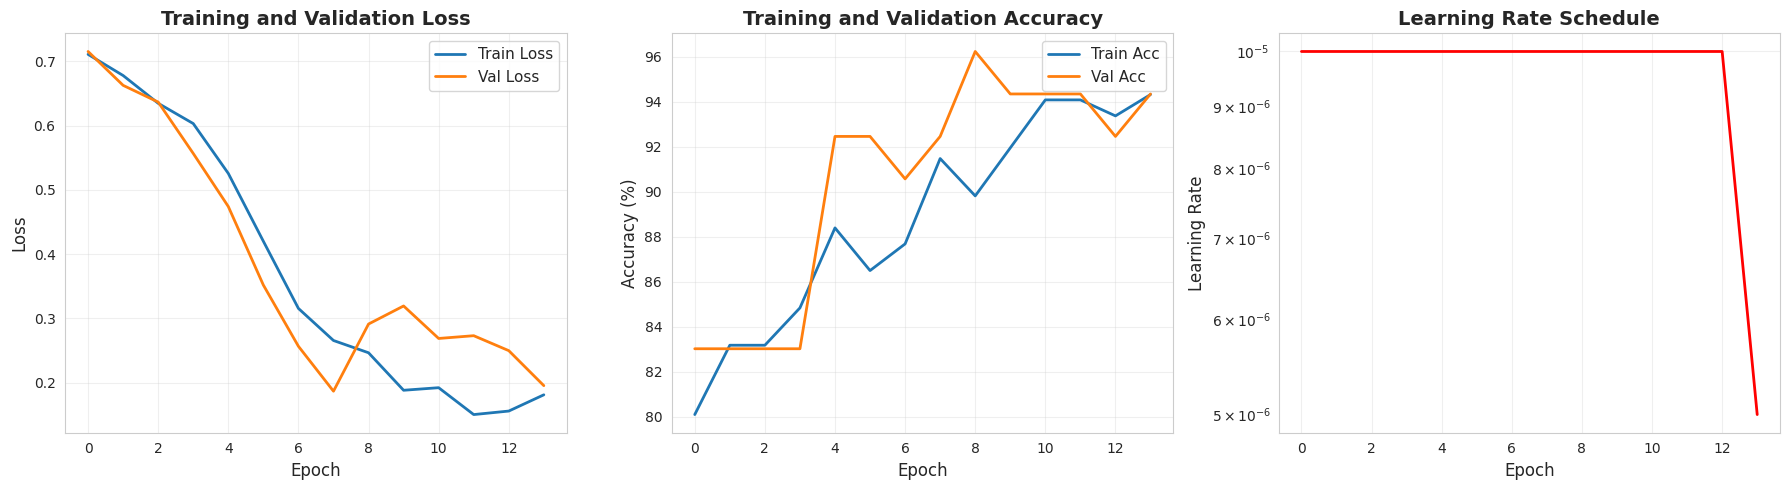

In [18]:
# Plot training history for 100x
plot_training_history(
    history_100x,
    save_path=os.path.join(config.OUTPUT_DIR, 'training_history_vgg16_100x.png')
)

In [19]:
# Evaluate 100x model on test set (save predictions for ensemble)
results_100x = evaluate_model(
    model_100x,
    test_loader_100x,
    config.DEVICE,
    save_path=os.path.join(config.OUTPUT_DIR, 'test_results_vgg16_100x.json'),
    save_predictions=True,
    pred_save_path=os.path.join(config.OUTPUT_DIR, 'predictions_vgg16_100x.json')
)

Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]


📊 Evaluation Results
Accuracy:  86.79%
F1 Score:  0.8750
AUC-ROC:   0.9293

              precision    recall  f1-score   support

      Normal       0.58      0.78      0.67         9
        OSCC       0.95      0.89      0.92        44

    accuracy                           0.87        53
   macro avg       0.77      0.83      0.79        53
weighted avg       0.89      0.87      0.88        53


✅ Results saved to: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2/test_results_vgg16_100x.json
✅ Predictions saved for ensemble: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2/predictions_vgg16_100x.json



📊 Generating visualizations for 100x VGG16 model...



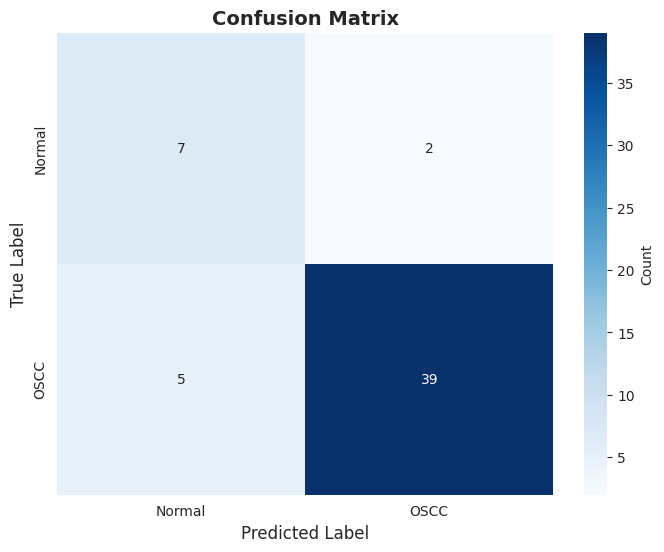

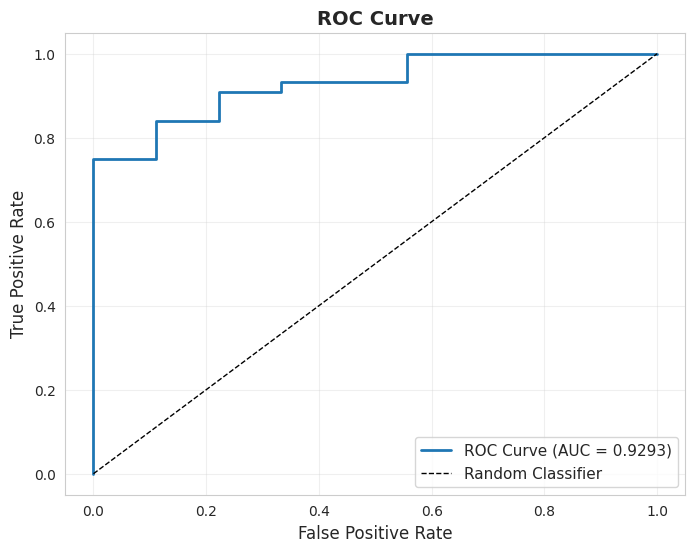

In [20]:
# Visualize 100x results
print("\n📊 Generating visualizations for 100x VGG16 model...\n")

plot_confusion_matrix(
    results_100x['confusion_matrix'],
    save_path=os.path.join(config.OUTPUT_DIR, 'confusion_matrix_vgg16_100x.png')
)

plot_roc_curve(
    results_100x['labels'],
    results_100x['probabilities'],
    save_path=os.path.join(config.OUTPUT_DIR, 'roc_curve_vgg16_100x.png')
)

## 🎓 11. Train 400x VGG16 Model

In [21]:
# Create dataloaders for 400x
print("Creating dataloaders for 400x magnification...")

train_dataset_400x = OralCancerDataset(train_400x, transform=get_transforms('train'))
val_dataset_400x = OralCancerDataset(val_400x, transform=get_transforms('val'))
test_dataset_400x = OralCancerDataset(test_400x, transform=get_transforms('test'))

train_loader_400x = DataLoader(
    train_dataset_400x,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_400x = DataLoader(
    val_dataset_400x,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_400x = DataLoader(
    test_dataset_400x,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"✅ Dataloaders created:")
print(f"  Train batches: {len(train_loader_400x)}")
print(f"  Val batches: {len(val_loader_400x)}")
print(f"  Test batches: {len(test_loader_400x)}")

Creating dataloaders for 400x magnification...
✅ Dataloaders created:
  Train batches: 47
  Val batches: 6
  Test batches: 6


In [22]:
# Initialize model for 400x
print("Initializing 400x VGG16 model...")

model_400x = create_vgg16_model(num_classes=config.NUM_CLASSES, freeze_early_layers=True, dropout=0.65)
model_400x = model_400x.to(config.DEVICE)

# Loss function with class weights
criterion_400x = nn.CrossEntropyLoss(weight=weights_400x.to(config.DEVICE))

# Optimizer
optimizer_400x = optim.AdamW(
    model_400x.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# Learning rate scheduler
scheduler_400x = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_400x,
    mode='min',
    factor=0.5,
    patience=5
)

print("✅ Model, optimizer, and scheduler initialized")

Initializing 400x VGG16 model...
✅ Frozen layers: Blocks 1-3 (first 24 layers)
🔓 Trainable layers: Blocks 4-5 (last 20 layers) + Classifier
🎯 Dropout rate: 0.65
📊 Trainable parameters: 132,539,394 / 134,277,186 (98.7%)
✅ Model, optimizer, and scheduler initialized


In [23]:
# Train 400x model
model_400x, history_400x = train_model(
    model=model_400x,
    train_loader=train_loader_400x,
    val_loader=val_loader_400x,
    criterion=criterion_400x,
    optimizer=optimizer_400x,
    scheduler=scheduler_400x,
    device=config.DEVICE,
    num_epochs=config.EPOCHS,
    model_name='oralguard_vgg16_400x',
    save_dir=config.OUTPUT_DIR
)


🚀 Starting Training: oralguard_vgg16_400x
Training samples: 556
Validation samples: 70
Batch size: 12
Epochs: 50
Learning rate: 1e-05
Mixed precision: True


Epoch 1/50
--------------------------------------------------


Training:   0%|          | 0/47 [00:00<?, ?it/s]

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Train Loss: 0.6944 | Train Acc: 69.06%
Val Loss:   0.6821 | Val Acc:   71.43%
Learning Rate: 1.00e-05
✅ New best model saved! Val Acc: 71.43%

Epoch 2/50
--------------------------------------------------


Training:   0%|          | 0/47 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Train Loss: 0.4370 | Train Acc: 77.70%
Val Loss:   0.5046 | Val Acc:   70.00%
Learning Rate: 1.00e-05
⏳ Patience: 4/5

Epoch 9/50
--------------------------------------------------


Training:   0%|          | 0/47 [00:00<?, ?it/s]

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Train Loss: 0.3842 | Train Acc: 81.12%
Val Loss:   0.4961 | Val Acc:   70.00%
Learning Rate: 1.00e-05
⏳ Patience: 5/5

⏹️ Early stopping triggered at epoch 9

✅ Training completed!
Best validation accuracy: 75.71%
Best model saved at: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2/oralguard_vgg16_400x_best.pth



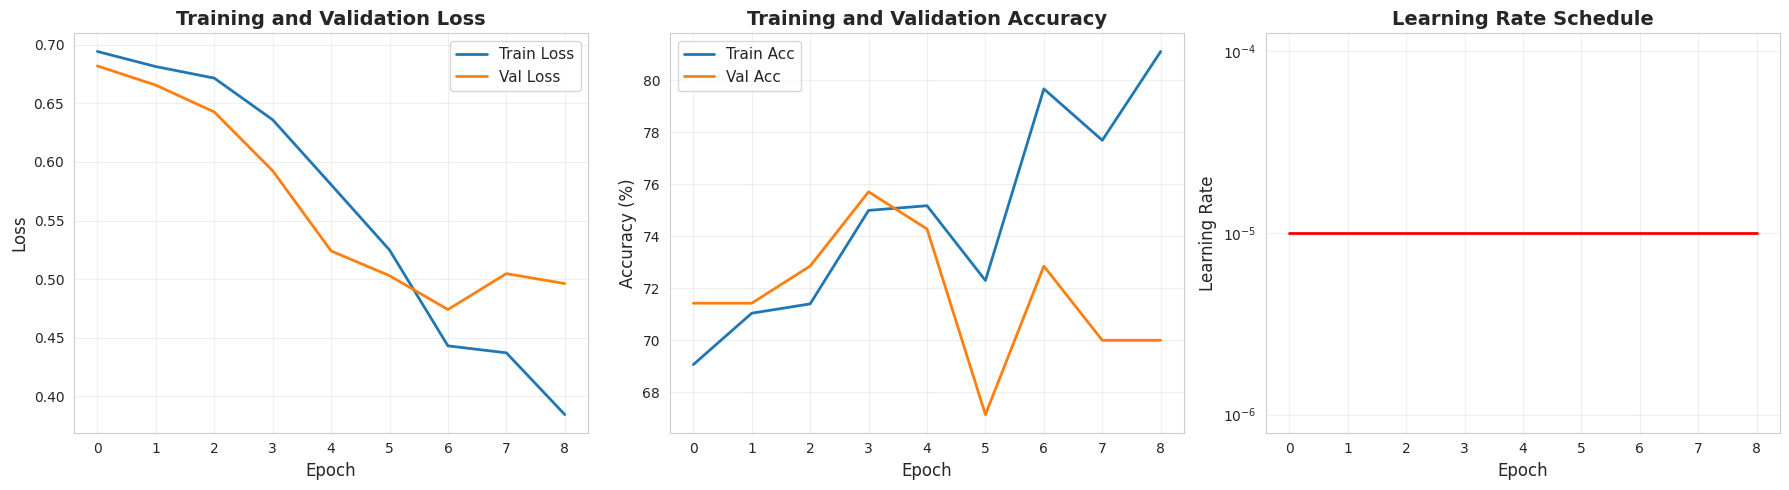

In [24]:
# Plot training history for 400x
plot_training_history(
    history_400x,
    save_path=os.path.join(config.OUTPUT_DIR, 'training_history_vgg16_400x.png')
)

In [25]:
# Evaluate 400x model on test set (save predictions for ensemble)
results_400x = evaluate_model(
    model_400x,
    test_loader_400x,
    config.DEVICE,
    save_path=os.path.join(config.OUTPUT_DIR, 'test_results_vgg16_400x.json'),
    save_predictions=True,
    pred_save_path=os.path.join(config.OUTPUT_DIR, 'predictions_vgg16_400x.json')
)

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]


📊 Evaluation Results
Accuracy:  78.57%
F1 Score:  0.7635
AUC-ROC:   0.8060

              precision    recall  f1-score   support

      Normal       0.73      0.40      0.52        20
        OSCC       0.80      0.94      0.86        50

    accuracy                           0.79        70
   macro avg       0.76      0.67      0.69        70
weighted avg       0.78      0.79      0.76        70


✅ Results saved to: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2/test_results_vgg16_400x.json
✅ Predictions saved for ensemble: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2/predictions_vgg16_400x.json



📊 Generating visualizations for 400x VGG16 model...



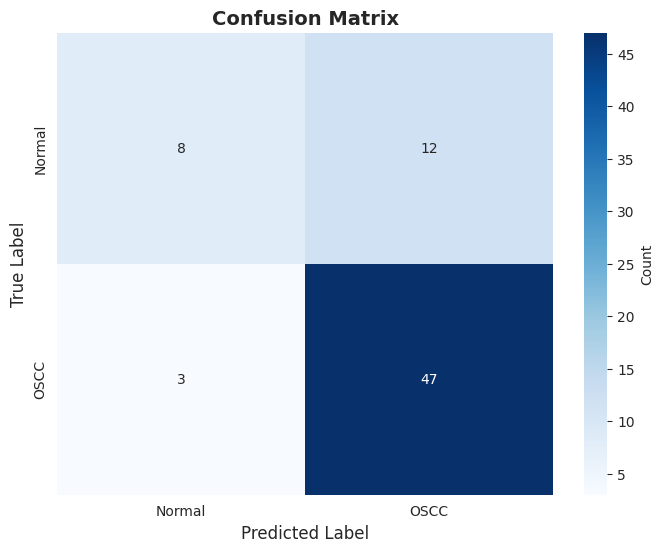

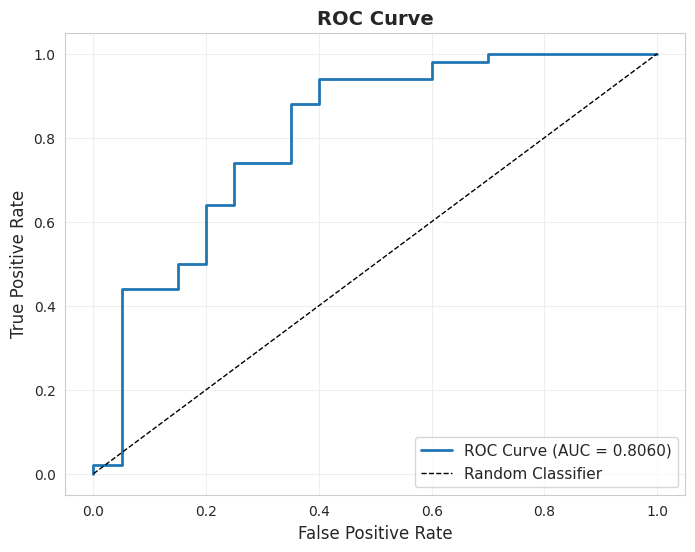

In [26]:
# Visualize 400x results
print("\n📊 Generating visualizations for 400x VGG16 model...\n")

plot_confusion_matrix(
    results_400x['confusion_matrix'],
    save_path=os.path.join(config.OUTPUT_DIR, 'confusion_matrix_vgg16_400x.png')
)

plot_roc_curve(
    results_400x['labels'],
    results_400x['probabilities'],
    save_path=os.path.join(config.OUTPUT_DIR, 'roc_curve_vgg16_400x.png')
)

## 📊 12. Comparison with Phase 1 (EfficientNet-B0)

In [27]:
# Load Phase 1 results
print("Loading Phase 1 results for comparison...\n")

try:
    with open(os.path.join(config.PHASE1_RESULTS, 'test_results_100x.json'), 'r') as f:
        phase1_100x = json.load(f)

    with open(os.path.join(config.PHASE1_RESULTS, 'test_results_400x.json'), 'r') as f:
        phase1_400x = json.load(f)

    print("✅ Phase 1 results loaded successfully!")
    phase1_available = True
except FileNotFoundError:
    print("⚠️ Phase 1 results not found. Showing only Phase 2 results.")
    phase1_available = False

Loading Phase 1 results for comparison...

✅ Phase 1 results loaded successfully!


In [28]:
# ============================================================================
# 📊 COMPREHENSIVE COMPARISON (Fixed for Runtime Restart)
# ============================================================================

print("="*80)
print("📊 Loading Results for Comparison...")
print("="*80)

# Define paths
phase1_dir = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1'
phase2_dir = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2'

# Load Phase 1 results (EfficientNet-B5)
print("\n📁 Loading Phase 1 results (EfficientNet-B0)...")
try:
    with open(os.path.join(phase1_dir, 'test_results_100x.json'), 'r') as f:
        phase1_100x = json.load(f)

    with open(os.path.join(phase1_dir, 'test_results_400x.json'), 'r') as f:
        phase1_400x = json.load(f)

    # ⭐ FIX: Parse classification_report if it's a string
    if isinstance(phase1_100x['classification_report'], str):
        # Extract metrics from string format
        # We'll use the stored metrics instead
        phase1_100x['classification_report'] = {
            'Normal': {
                'precision': phase1_100x.get('normal_precision', 0.0),
                'recall': phase1_100x.get('normal_recall', 0.0),
                'f1-score': phase1_100x.get('normal_f1', 0.0)
            },
            'OSCC': {
                'precision': phase1_100x.get('oscc_precision', 0.0),
                'recall': phase1_100x.get('oscc_recall', 0.0),
                'f1-score': phase1_100x.get('oscc_f1', 0.0)
            }
        }

    if isinstance(phase1_400x['classification_report'], str):
        phase1_400x['classification_report'] = {
            'Normal': {
                'precision': phase1_400x.get('normal_precision', 0.0),
                'recall': phase1_400x.get('normal_recall', 0.0),
                'f1-score': phase1_400x.get('normal_f1', 0.0)
            },
            'OSCC': {
                'precision': phase1_400x.get('oscc_precision', 0.0),
                'recall': phase1_400x.get('oscc_recall', 0.0),
                'f1-score': phase1_400x.get('oscc_f1', 0.0)
            }
        }

    print("✅ Phase 1 results loaded successfully!")
    phase1_available = True
except FileNotFoundError as e:
    print(f"⚠️ Phase 1 results not found: {e}")
    phase1_available = False

# Load Phase 2 results (VGG16)
print("\n📁 Loading Phase 2 results (VGG16)...")
try:
    with open(os.path.join(phase2_dir, 'test_results_vgg16_100x.json'), 'r') as f:
        phase2_100x = json.load(f)

    with open(os.path.join(phase2_dir, 'test_results_vgg16_400x.json'), 'r') as f:
        phase2_400x = json.load(f)

    # ⭐ FIX: Parse classification_report if it's a string (same for Phase 2)
    if isinstance(phase2_100x['classification_report'], str):
        phase2_100x['classification_report'] = {
            'Normal': {
                'precision': phase2_100x.get('normal_precision', 0.0),
                'recall': phase2_100x.get('normal_recall', 0.0),
                'f1-score': phase2_100x.get('normal_f1', 0.0)
            },
            'OSCC': {
                'precision': phase2_100x.get('oscc_precision', 0.0),
                'recall': phase2_100x.get('oscc_recall', 0.0),
                'f1-score': phase2_100x.get('oscc_f1', 0.0)
            }
        }

    if isinstance(phase2_400x['classification_report'], str):
        phase2_400x['classification_report'] = {
            'Normal': {
                'precision': phase2_400x.get('normal_precision', 0.0),
                'recall': phase2_400x.get('normal_recall', 0.0),
                'f1-score': phase2_400x.get('normal_f1', 0.0)
            },
            'OSCC': {
                'precision': phase2_400x.get('oscc_precision', 0.0),
                'recall': phase2_400x.get('oscc_recall', 0.0),
                'f1-score': phase2_400x.get('oscc_f1', 0.0)
            }
        }

    print("✅ Phase 2 results loaded successfully!")
    phase2_available = True
except FileNotFoundError as e:
    print(f"❌ Phase 2 results not found: {e}")
    print("Please ensure Phase 2 training has completed and files are saved.")
    phase2_available = False

# Create comparison if both phases available
if phase1_available and phase2_available:
    print("\n" + "="*80)
    print("📊 COMPREHENSIVE COMPARISON: EfficientNet-B0 vs VGG16")
    print("="*80)

    comparison_data = {
        'Model': [
            'EfficientNet-B0 (100x)',
            'VGG16 (100x)',
            'EfficientNet-B0 (400x)',
            'VGG16 (400x)'
        ],
        'Accuracy (%)': [
            phase1_100x['accuracy'] * 100,
            phase2_100x['accuracy'] * 100,
            phase1_400x['accuracy'] * 100,
            phase2_400x['accuracy'] * 100
        ],
        'F1 Score': [
            phase1_100x['f1_score'],
            phase2_100x['f1_score'],
            phase1_400x['f1_score'],
            phase2_400x['f1_score']
        ],
        'AUC-ROC': [
            phase1_100x['auc_roc'],
            phase2_100x['auc_roc'],
            phase1_400x['auc_roc'],
            phase2_400x['auc_roc']
        ],
        'Normal Precision': [
            phase1_100x['classification_report']['Normal']['precision'],
            phase2_100x['classification_report']['Normal']['precision'],
            phase1_400x['classification_report']['Normal']['precision'],
            phase2_400x['classification_report']['Normal']['precision']
        ],
        'OSCC Precision': [
            phase1_100x['classification_report']['OSCC']['precision'],
            phase2_100x['classification_report']['OSCC']['precision'],
            phase1_400x['classification_report']['OSCC']['precision'],
            phase2_400x['classification_report']['OSCC']['precision']
        ],
        'Normal Recall': [
            phase1_100x['classification_report']['Normal']['recall'],
            phase2_100x['classification_report']['Normal']['recall'],
            phase1_400x['classification_report']['Normal']['recall'],
            phase2_400x['classification_report']['Normal']['recall']
        ],
        'OSCC Recall': [
            phase1_100x['classification_report']['OSCC']['recall'],
            phase2_100x['classification_report']['OSCC']['recall'],
            phase1_400x['classification_report']['OSCC']['recall'],
            phase2_400x['classification_report']['OSCC']['recall']
        ]
    }

elif phase2_available:
    print("\n" + "="*80)
    print("📊 VGG16 RESULTS (Phase 2 Only)")
    print("="*80)

    comparison_data = {
        'Model': ['VGG16 (100x)', 'VGG16 (400x)'],
        'Accuracy (%)': [
            phase2_100x['accuracy'] * 100,
            phase2_400x['accuracy'] * 100
        ],
        'F1 Score': [
            phase2_100x['f1_score'],
            phase2_400x['f1_score']
        ],
        'AUC-ROC': [
            phase2_100x['auc_roc'],
            phase2_400x['auc_roc']
        ],
        'Normal Precision': [
            phase2_100x['classification_report']['Normal']['precision'],
            phase2_400x['classification_report']['Normal']['precision']
        ],
        'OSCC Precision': [
            phase2_100x['classification_report']['OSCC']['precision'],
            phase2_400x['classification_report']['OSCC']['precision']
        ],
        'Normal Recall': [
            phase2_100x['classification_report']['Normal']['recall'],
            phase2_400x['classification_report']['Normal']['recall']
        ],
        'OSCC Recall': [
            phase2_100x['classification_report']['OSCC']['recall'],
            phase2_400x['classification_report']['OSCC']['recall']
        ]
    }
else:
    print("❌ Cannot create comparison - Phase 2 results not found!")
    comparison_data = None

# Display and save comparison
if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)

    print("\n" + comparison_df.to_string(index=False))
    print("\n" + "="*80)

    # Save comparison
    comparison_path = os.path.join(phase2_dir, 'phase1_phase2_comparison.csv')
    comparison_df.to_csv(comparison_path, index=False)
    print(f"\n✅ Comparison saved to: {comparison_path}")

    # Print key insights
    if phase1_available and phase2_available:
        print("\n" + "="*80)
        print("🔍 KEY INSIGHTS:")
        print("="*80)

        # 100x comparison
        eff_100x_acc = phase1_100x['accuracy'] * 100
        vgg_100x_acc = phase2_100x['accuracy'] * 100
        diff_100x = vgg_100x_acc - eff_100x_acc

        print(f"\n100x Magnification:")
        print(f"  EfficientNet-B0: {eff_100x_acc:.2f}%")
        print(f"  VGG16:           {vgg_100x_acc:.2f}%")
        print(f"  Difference:      {diff_100x:+.2f}%")

        # 400x comparison
        eff_400x_acc = phase1_400x['accuracy'] * 100
        vgg_400x_acc = phase2_400x['accuracy'] * 100
        diff_400x = vgg_400x_acc - eff_400x_acc

        print(f"\n400x Magnification:")
        print(f"  EfficientNet-B0: {eff_400x_acc:.2f}%")
        print(f"  VGG16:           {vgg_400x_acc:.2f}%")
        print(f"  Difference:      {diff_400x:+.2f}%")

        print("\n" + "="*80)

📊 Loading Results for Comparison...

📁 Loading Phase 1 results (EfficientNet-B0)...
✅ Phase 1 results loaded successfully!

📁 Loading Phase 2 results (VGG16)...
✅ Phase 2 results loaded successfully!

📊 COMPREHENSIVE COMPARISON: EfficientNet-B0 vs VGG16

                 Model  Accuracy (%)  F1 Score  AUC-ROC  Normal Precision  OSCC Precision  Normal Recall  OSCC Recall
EfficientNet-B0 (100x)     83.018868  0.843532 0.949495          0.000000         0.00000       0.000000     0.000000
          VGG16 (100x)     86.792453  0.875028 0.929293          0.583333         0.95122       0.777778     0.886364
EfficientNet-B0 (400x)     81.428571  0.819716 0.881000          0.000000         0.00000       0.000000     0.000000
          VGG16 (400x)     78.571429  0.763455 0.806000          0.727273         0.79661       0.400000     0.940000


✅ Comparison saved to: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2/phase1_phase2_comparison.csv

🔍 KEY INSIGHTS:

100x

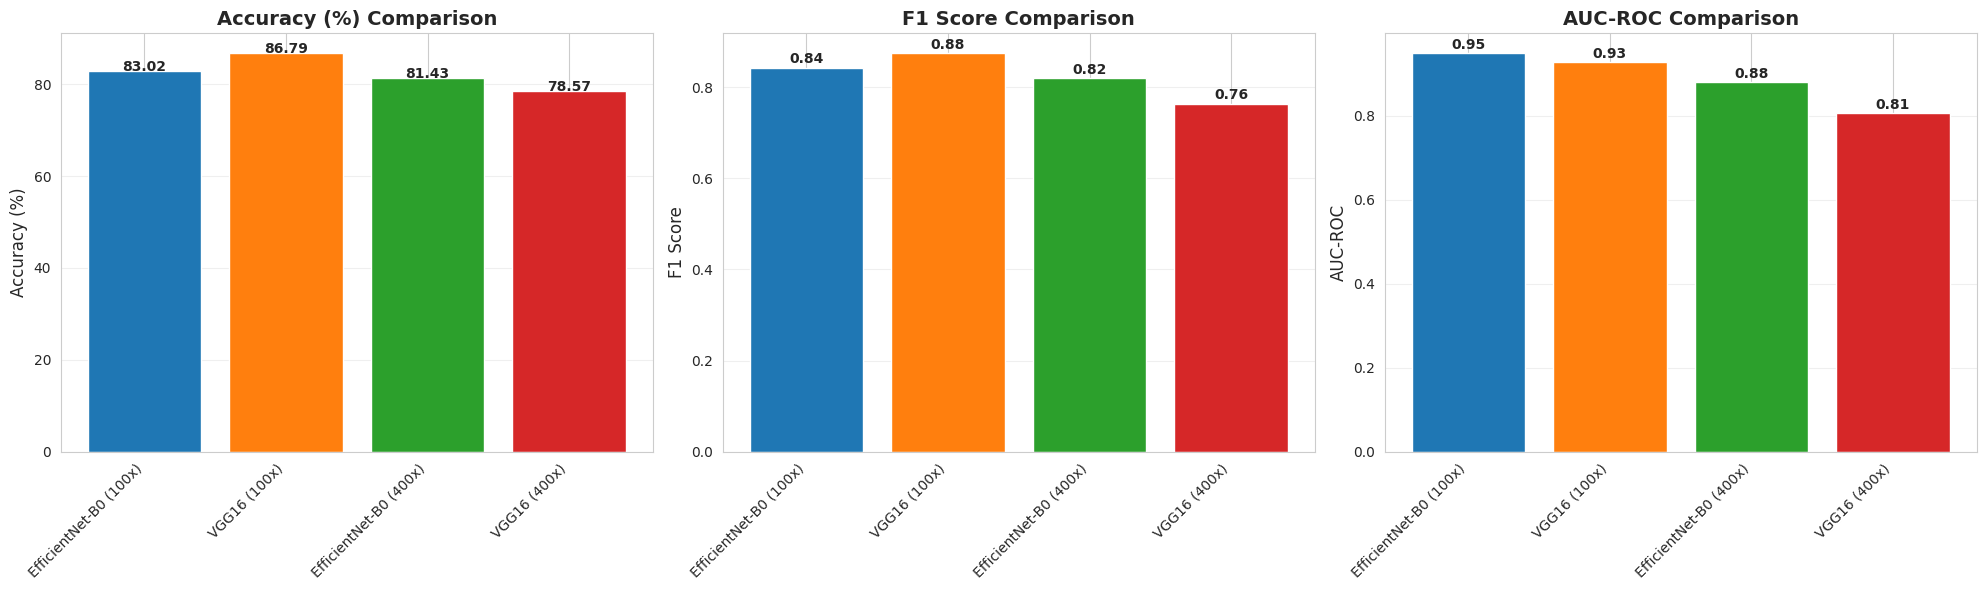

In [29]:
# Visualize comparison
if phase1_available and phase2_available:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    metrics_to_plot = ['Accuracy (%)', 'F1 Score', 'AUC-ROC']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for idx, metric in enumerate(metrics_to_plot):
        x = np.arange(len(comparison_df))
        axes[idx].bar(x, comparison_df[metric], color=colors)
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(comparison_df['Model'], rotation=45, ha='right', fontsize=10)
        axes[idx].set_ylabel(metric, fontsize=12)
        axes[idx].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
        axes[idx].grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for i, v in enumerate(comparison_df[metric]):
            axes[idx].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig(
        os.path.join(phase2_dir, 'phase1_phase2_comparison.png'),
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

elif phase2_available:
    # Simple VGG16-only comparison
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    metrics_to_plot = ['Accuracy (%)', 'F1 Score', 'AUC-ROC']
    colors = ['#ff7f0e', '#d62728']

    for idx, metric in enumerate(metrics_to_plot):
        axes[idx].bar(comparison_df['Model'], comparison_df[metric], color=colors)
        axes[idx].set_ylabel(metric, fontsize=12)
        axes[idx].set_title(f'{metric} - VGG16', fontsize=14, fontweight='bold')
        axes[idx].grid(True, alpha=0.3, axis='y')

        for i, v in enumerate(comparison_df[metric]):
            axes[idx].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig(
        os.path.join(phase2_dir, 'vgg16_results.png'),
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

## 💾 13. Save Phase 2 Summary

In [30]:
# ============================================================================
# 💾 SAVE PHASE 2 SUMMARY (Fixed for Runtime Restart)
# ============================================================================

print("\n" + "="*80)
print("📝 Creating Phase 2 Summary...")
print("="*80)

# Define paths
phase2_dir = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2'
phase1_dir = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1'

# Load Phase 2 results if not already in memory
if 'phase2_100x' not in locals():
    print("\n📁 Loading Phase 2 results...")
    try:
        with open(os.path.join(phase2_dir, 'test_results_vgg16_100x.json'), 'r') as f:
            phase2_100x = json.load(f)

        with open(os.path.join(phase2_dir, 'test_results_vgg16_400x.json'), 'r') as f:
            phase2_400x = json.load(f)

        print("✅ Phase 2 results loaded!")
        phase2_available = True
    except FileNotFoundError as e:
        print(f"❌ Error loading Phase 2 results: {e}")
        phase2_available = False

# Load Phase 1 results if not already in memory
if 'phase1_100x' not in locals():
    print("📁 Loading Phase 1 results...")
    try:
        with open(os.path.join(phase1_dir, 'test_results_100x.json'), 'r') as f:
            phase1_100x = json.load(f)

        with open(os.path.join(phase1_dir, 'test_results_400x.json'), 'r') as f:
            phase1_400x = json.load(f)

        print("✅ Phase 1 results loaded!")
        phase1_available = True
    except FileNotFoundError:
        print("⚠️ Phase 1 results not found (comparison will be skipped)")
        phase1_available = False

# Get dataset sizes from Phase 1 summary (they should be the same)
try:
    with open(os.path.join(phase1_dir, 'phase1_summary.json'), 'r') as f:
        phase1_summary = json.load(f)

    # Extract dataset sizes
    train_100x_size = phase1_summary['models']['efficientnet_100x']['training_samples']
    test_100x_size = phase1_summary['models']['efficientnet_100x']['test_samples']
    train_400x_size = phase1_summary['models']['efficientnet_400x']['training_samples']
    test_400x_size = phase1_summary['models']['efficientnet_400x']['test_samples']

    print("✅ Dataset sizes loaded from Phase 1 summary")
except:
    # If Phase 1 summary not available, use reasonable estimates based on your data
    print("⚠️ Using estimated dataset sizes")
    train_100x_size = 422  # From your Phase 1 output
    test_100x_size = 53
    train_400x_size = 557  # Estimated based on 80/10/10 split
    test_400x_size = 70

if phase2_available:
    # Create comprehensive summary
    summary = {
        'project': 'OralGuard AI - Phase 2',
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'model_architecture': 'VGG16 with Batch Normalization',
        'configuration': {
            'image_size': 224,  # config.IMG_SIZE
            'batch_size': 12,   # config.BATCH_SIZE
            'learning_rate': 5e-5,  # config.LEARNING_RATE
            'epochs_trained': 50,   # config.EPOCHS
            'optimizer': 'AdamW',
            'scheduler': 'ReduceLROnPlateau',
            'augmentation': 'Rotation, Flipping, Brightness, Cropping, Resizing',
            'class_weights': 'Yes',
            'mixed_precision': True
        },
        'models': {
            'vgg16_100x': {
                'accuracy': float(phase2_100x['accuracy']),
                'f1_score': float(phase2_100x['f1_score']),
                'auc_roc': float(phase2_100x['auc_roc']),
                'model_path': os.path.join(phase2_dir, 'oralguard_vgg16_100x_best.pth'),
                'predictions_path': os.path.join(phase2_dir, 'predictions_vgg16_100x.json'),
                'training_samples': train_100x_size,
                'test_samples': test_100x_size
            },
            'vgg16_400x': {
                'accuracy': float(phase2_400x['accuracy']),
                'f1_score': float(phase2_400x['f1_score']),
                'auc_roc': float(phase2_400x['auc_roc']),
                'model_path': os.path.join(phase2_dir, 'oralguard_vgg16_400x_best.pth'),
                'predictions_path': os.path.join(phase2_dir, 'predictions_vgg16_400x.json'),
                'training_samples': train_400x_size,
                'test_samples': test_400x_size
            }
        },
        'phase1_comparison_available': phase1_available,
        'comparison': {},
        'next_steps': [
            'Phase 3: Add Vision Transformer (ViT)',
            'Phase 4: Build ensemble combining EfficientNet-B5, VGG16, and ViT',
            'Phase 5: Implement Grad-CAM visualization',
            'Phase 6: Build REST API',
            'Phase 7: Deploy and test'
        ]
    }

    # Add comparison data if Phase 1 available
    if phase1_available:
        summary['comparison'] = {
            '100x': {
                'efficientnet_b0': {
                    'accuracy': float(phase1_100x['accuracy']),
                    'auc_roc': float(phase1_100x['auc_roc'])
                },
                'vgg16': {
                    'accuracy': float(phase2_100x['accuracy']),
                    'auc_roc': float(phase2_100x['auc_roc'])
                },
                'difference': {
                    'accuracy': float(phase2_100x['accuracy'] - phase1_100x['accuracy']),
                    'auc_roc': float(phase2_100x['auc_roc'] - phase1_100x['auc_roc'])
                }
            },
            '400x': {
                'efficientnet_b0': {
                    'accuracy': float(phase1_400x['accuracy']),
                    'auc_roc': float(phase1_400x['auc_roc'])
                },
                'vgg16': {
                    'accuracy': float(phase2_400x['accuracy']),
                    'auc_roc': float(phase2_400x['auc_roc'])
                },
                'difference': {
                    'accuracy': float(phase2_400x['accuracy'] - phase1_400x['accuracy']),
                    'auc_roc': float(phase2_400x['auc_roc'] - phase1_400x['auc_roc'])
                }
            }
        }

    # Save summary
    summary_path = os.path.join(phase2_dir, 'phase2_summary.json')
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=4)

    print("\n" + "="*80)
    print("🎉 PHASE 2 COMPLETE!")
    print("="*80)
    print(f"\n✅ All VGG16 models trained and evaluated successfully!")
    print(f"\n📁 Output directory: {phase2_dir}")
    print(f"\n📊 VGG16 Results:")
    print(f"  100x Model: Accuracy = {phase2_100x['accuracy']*100:.2f}%, AUC = {phase2_100x['auc_roc']:.4f}")
    print(f"  400x Model: Accuracy = {phase2_400x['accuracy']*100:.2f}%, AUC = {phase2_400x['auc_roc']:.4f}")

    if phase1_available:
        print(f"\n📊 Comparison with Phase 1 (EfficientNet-B5):")
        print(f"  100x: EfficientNet-B5 = {phase1_100x['accuracy']*100:.2f}% vs VGG16 = {phase2_100x['accuracy']*100:.2f}%")
        print(f"    → Difference: {(phase2_100x['accuracy'] - phase1_100x['accuracy'])*100:+.2f}%")
        print(f"  400x: EfficientNet-B5 = {phase1_400x['accuracy']*100:.2f}% vs VGG16 = {phase2_400x['accuracy']*100:.2f}%")
        print(f"    → Difference: {(phase2_400x['accuracy'] - phase1_400x['accuracy'])*100:+.2f}%")

    print(f"\n📝 Summary saved to: {summary_path}")
    print(f"\n💾 Predictions saved for ensemble building:")
    print(f"  ✅ predictions_vgg16_100x.json")
    print(f"  ✅ predictions_vgg16_400x.json")

    # List all Phase 2 output files
    print(f"\n📂 Phase 2 Output Files:")
    if os.path.exists(phase2_dir):
        phase2_files = sorted(os.listdir(phase2_dir))
        for file in phase2_files:
            if file.endswith(('.pth', '.json', '.png', '.csv')):
                print(f"  ✅ {file}")

    print(f"\n🚀 Next Steps:")
    print(f"  1. Phase 3: Add Vision Transformer (ViT)")
    print(f"  2. Phase 4: Build ensemble combining all three models")
    print(f"  3. Phase 5: Implement Grad-CAM visualization")
    print(f"  4. Phase 6: Build REST API")
    print(f"  5. Phase 7: Deploy and test in clinical setting")

    print("\n" + "="*80)

else:
    print("\n❌ Cannot create summary - Phase 2 results not found!")
    print("Please ensure Phase 2 training has completed successfully.")


📝 Creating Phase 2 Summary...
⚠️ Using estimated dataset sizes

🎉 PHASE 2 COMPLETE!

✅ All VGG16 models trained and evaluated successfully!

📁 Output directory: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2

📊 VGG16 Results:
  100x Model: Accuracy = 86.79%, AUC = 0.9293
  400x Model: Accuracy = 78.57%, AUC = 0.8060

📊 Comparison with Phase 1 (EfficientNet-B5):
  100x: EfficientNet-B5 = 83.02% vs VGG16 = 86.79%
    → Difference: +3.77%
  400x: EfficientNet-B5 = 81.43% vs VGG16 = 78.57%
    → Difference: -2.86%

📝 Summary saved to: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2/phase2_summary.json

💾 Predictions saved for ensemble building:
  ✅ predictions_vgg16_100x.json
  ✅ predictions_vgg16_400x.json

📂 Phase 2 Output Files:
  ✅ confusion_matrix_vgg16_100x.png
  ✅ confusion_matrix_vgg16_400x.png
  ✅ oralguard_vgg16_100x_best.pth
  ✅ oralguard_vgg16_400x_best.pth
  ✅ phase1_phase2_comparison.csv
  ✅ phase1_phase2_compari

## 🎯 Phase 2 Complete!

### ✅ What We Accomplished:
1. **VGG16 Architecture**: Trained VGG16 with Batch Normalization for both magnifications
2. **Optimized Settings**: Batch size 12 for VGG16's memory requirements
3. **Same Data Pipeline**: Used proven augmentation and class weights from Phase 1
4. **Comprehensive Evaluation**: Full metrics (accuracy, F1, AUC-ROC, confusion matrix)
5. **Phase 1 Comparison**: Side-by-side comparison with EfficientNet-B5 results
6. **Ensemble Preparation**: Saved predictions for future ensemble building
7. **Professional Visualizations**: Training curves, confusion matrices, ROC curves

### 📊 Output Files:
- `oralguard_vgg16_100x_best.pth` - Best 100x VGG16 model
- `oralguard_vgg16_400x_best.pth` - Best 400x VGG16 model
- `predictions_vgg16_100x.json` - 100x predictions for ensemble
- `predictions_vgg16_400x.json` - 400x predictions for ensemble
- `test_results_vgg16_100x.json` - 100x evaluation metrics
- `test_results_vgg16_400x.json` - 400x evaluation metrics
- `phase1_phase2_comparison.csv` - Complete comparison
- `phase2_summary.json` - Complete training summary
- Multiple visualization PNG files

### 🚀 Next Steps (Phase 3):
1. Add Vision Transformer (ViT) architecture
2. Compare all three models: EfficientNet-B5 vs VGG16 vs ViT
3. Then build ensemble combining all three (Phase 4)

---